In [3]:
import torch 

In [22]:
torch.xpu.is_available()

True

In [24]:
torch.xpu.get_device_properties()

_XpuDeviceProperties(name='Intel(R) Arc(TM) Graphics', platform_name='Intel(R) oneAPI Unified Runtime over Level-Zero', type='gpu', driver_version='1.6.33578+15', total_memory=13637MB, max_compute_units=128, gpu_eu_count=128, gpu_subslice_count=8, max_work_group_size=1024, max_num_sub_groups=128, sub_group_sizes=[8 16 32], has_fp16=1, has_fp64=1, has_atomic64=1)

Donanım Kimliği: Intel(R) Arc(TM) Graphics modelini ve sürücü versiyonunu (1.6.33578) belirtir.

Bellek (VRAM): Toplam 13.6 GB (13637MB) kullanılabilir video belleğin var. Büyük modelleri yüklemek için yeterli bir alan.

İşlem Gücü: 128 adet Compute Unit (Hesaplama Birimi) ve 128 EU (Execution Unit) içeriyor. Paralel işlemleri bu birimler üzerinden yürütür.

Yazılım Katmanı: oneAPI ve Level-Zero sürücülerini kullanıyor; bu, Intel'in donanımı PyTorch gibi kütüphanelerle konuşturmak için kullandığı köprüdür.

Hassasiyet Desteği: has_fp16=1 ve has_fp64=1 olması, hem yarım hassasiyet (hızlı eğitim/çıkarım) hem de tam hassasiyetli matematiksel işlemleri yapabildiğini gösterir.

Grup Limitleri: max_work_group_size=1024, bir çekirdek (kernel) işleminde aynı anda en fazla 1024 iş parçacığının bir arada çalışabileceğini ifade eder.

In [25]:
from datasets import load_dataset 
#Hugging Face Datasets, ses, metin ve görüntü gibi farklı veri türlerine tek bir satırla erişmenizi sağlayan açık kaynaklı bir kütüphanedir.
dataset = load_dataset("ag_news")
#Veri setini Hugging Face Hub'dan bulur ve yerel diskinize indirir.
print(dataset)


/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating test split: 100%|██████████| 7600/7600 [00:00<00:00, 1182502.15 examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


In [26]:
#DatasetDict (Ana Kutu): Tüm veri setini bir arada tutan bir klasör gibidir.
#Test ve eğitim data ayrı ayrı dictlenmiş
type(dataset)

datasets.dataset_dict.DatasetDict

In [28]:
dataset["train"]["text"] # iç içe dict gibi

Column(["Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\\which has a reputation for making well-timed and occasionally\\controversial plays in the defense industry, has quietly placed\\its bets on another part of the market.', "Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\\about the economy and the outlook for earnings are expected to\\hang over the stock market next week during the depth of the\\summer doldrums.", 'Iraq Halts Oil Exports from Main Southern Pipeline (Reuters) Reuters - Authorities have halted oil export\\flows from the main pipeline in southern Iraq after\\intelligence showed a rebel militia could strike\\infrastructure, an oil official said on Saturday.', 'Oil prices soar to all-time record, posing new menace to US economy

In [31]:
df_train = pd.DataFrame(dataset["train"])
#dataset.set_format(type="pandas") Alternatif yöntem
#Sadece traini yapmamız yeterli hazır bir veri seti

In [32]:
df_train.describe()

,label
count,120000.000000
mean,1.500000
std,1.118039
min,0.000000
25%,0.750000
50%,1.500000
75%,2.250000
max,3.000000


In [36]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    120000 non-null  object
 1   label   120000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.8+ MB


In [37]:
print(df_train['label'].value_counts())

label
2    30000
3    30000
1    30000
0    30000
Name: count, dtype: int64


In [38]:
dataset["train"].features["label"].names

['World', 'Sports', 'Business', 'Sci/Tech']

In [46]:
print(dataset["train"].features["label"])
#class label kategorik değişken
#Benim 'label' adında bir sütunum var. Bu bir ClassLabel tipindedir. Eğer içinde 1 görürsen, bu aslında 'Sports' demektir.

ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'])


In [47]:
# Etiket isimlerini çekelim
label_names = dataset["train"].features["label"].names

# Sayıları isimlere eşleyelim
df_train['category_name'] = df_train['label'].apply(lambda x: label_names[x])

# Kontrol edelim
print(df_train[['text', 'category_name']].head())

                                                text category_name
0  Wall St. Bears Claw Back Into the Black (Reute...      Business
1  Carlyle Looks Toward Commercial Aerospace (Reu...      Business
2  Oil and Economy Cloud Stocks' Outlook (Reuters...      Business
3  Iraq Halts Oil Exports from Main Southern Pipe...      Business
4  Oil prices soar to all-time record, posing new...      Business


/tmp/ipykernel_370/2078349701.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x='category_name', palette='viridis')


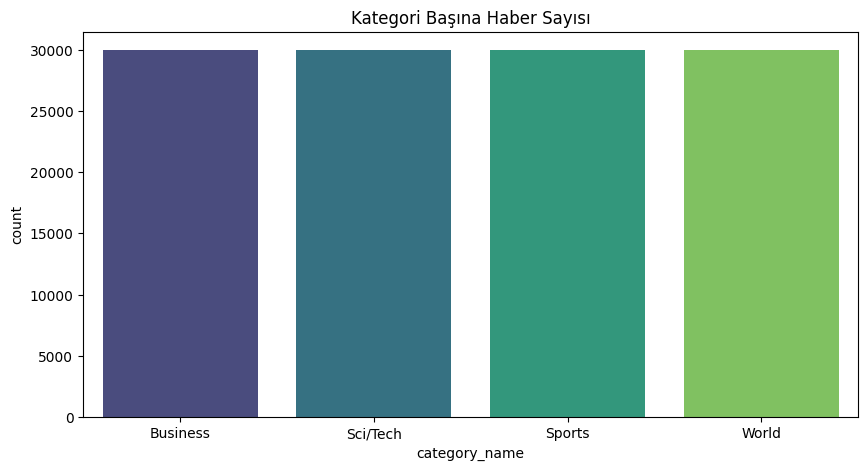

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(data=df_train, x='category_name', palette='viridis')
plt.title('Kategori Başına Haber Sayısı')
plt.show()

Bilgisayarlar kelimeleri, harfleri ya da cümleleri okuyamaz. Onlar sadece sayıları anlar. Bir yapay zeka modeline "Bugün hava çok güzel" dediğinde, o bunu anlayabilmek için önce sayı dizilerine çevirmek zorundadır.

İşte AutoTokenizer bu çeviriyi yapan **"Süper Tercüman"**dır.

Neden "Süper" diyoruz?
Dünyada binlerce farklı yapay zeka modeli var (BERT, GPT, RoBERTa gibi). Her birinin kendine has bir "sayı sözlüğü" vardır.

Bir model için "Hava" kelimesi 45 sayısıyken, diğeri için 1082 olabilir.

Eğer yanlış sözlüğü kullanırsan, modelin kafası karışır ve saçmalar.

In [59]:
from transformers import AutoTokenizer


tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
#from_pretrained (Önceden Eğitilmiş Bilgiyi Getir)
#"Git ve internetten (Hugging Face sunucularından) bu modelin daha önce öğrendiği sözlüğü ve kuralları indir"

#distilbert: BERT modelinin daha hafif ve hızlı bir versiyonu
#uncased: "Küçük-büyük harf ayrımı yapma" demektir. Yani "Haber" ile "haber" kelimesini aynı sayıya çevirir.

text = "Mustafa is exploring AG News dataset."
tokens = tokenizer.tokenize(text)
#Bu fonksiyon, senin verdiğin ham metni alıp DistilBERT modelinin anladığı en küçük birimlere (parçalara) böler. 
#Ancak bunu yaparken sadece boşluklara bakmaz, modelin "sözlük hafızasını" kullanır.


print(tokenizee) 

## işareti, bilgisayara şunu söyler: "Ben tek başıma bir kelime değilim, beni hemen önümdeki parçaya yapıştır!"

['mustafa', 'is', 'exploring', 'ag', 'news', 'data', '##set', '.']


Modelin "Sözlüğü" Bir Kitap Gibidir
Modelin elinde 30.000 kelimelik bir sözlük var. Ama dünyada milyonlarca kelime ve bunların ek almış halleri (geldi, gitmişti, Mustafa'nın...) var.

Eğer model her kelimenin her halini ezberlemeye kalksaydı, sözlüğü devasa olurdu ve bilgisayarın hafızası yetmezdi.

Bunun yerine model, en çok kullanılan parçaları ezberler.

In [63]:
text_2="Neden sayılar değilde kelimeler görüyorum"
tokens_tokanize=tokenizer.tokenize(text_2)
print(tokens_tokanize)

['ned', '##en', 'say', '##ı', '##lar', 'de', '##gil', '##de', 'ke', '##lim', '##ele', '##r', 'go', '##ru', '##yo', '##rum']


tokenizer.tokenize() komutu, cümleyi sayılara çevirmeden hemen önceki son "insanca" adımdır. * Sen "dataset" yazdın, o bunu ['data', '##set'] yaptı. 

In [64]:
ids = tokenizer.convert_tokens_to_ids(tokens_tokanize)
print(ids)

[12311, 2368, 2360, 11722, 8017, 2139, 20142, 3207, 17710, 17960, 12260, 2099, 2175, 6820, 7677, 6824]


In [65]:
inputs = tokenizer("Mustafa is exploring AG News dataset.")
print(inputs["input_ids"])

[101, 19683, 2003, 11131, 12943, 2739, 2951, 13462, 1012, 102]


101 ([CLS]): "Dikkat! Yeni bir cümle başlıyor."

102 ([SEP]): "Tamam, cümle burada bitti."

Her Rakam Bir "Etiket"tir
Modelin elinde (DistilBERT için) yaklaşık 30.522 kelime veya kelime parçasından oluşan dev bir liste var.

Sen "Mustafa" dediğinde, tokenizer bu listeye bakar.

"mustafa" kelimesini listenin 19683. sırasında bulur.

Artık bilgisayar için bu kelime sadece 19683 sayısıdır

Eğitim Seti (%95): Modeli "eğitmek" ve ağırlıklarını güncellemek için.

Validation Seti (%5): Eğitimin nasıl gittiğini "izlemek" ve en iyi ayarları seçmek için.

Test Seti (Ayrı): Her şey bittikten sonra modelin gerçek dünyadaki "final sınavı" için.

In [70]:
#Mevcut 'train' kısmını %95 eğitim ve %5 doğrulama (validation) olarak bölüyoruz
# 'seed' kullanıyoruz ki her çalıştırdığımızda aynı rastgele bölme yapılsın
split_dataset = dataset["train"].train_test_split(test_size=0.05, seed=42)

In [71]:
split_dataset
#train split test ile bölünen 120000 binlik alanın %5 i test oldu 114 bin ise train

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 114000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 6000
    })
})

In [77]:
split_dataset["validation"]=split_dataset["test"]

In [80]:
split_dataset.pop("test")

Dataset({
    features: ['text', 'label'],
    num_rows: 6000
})

In [81]:
split_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 114000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 6000
    })
})

In [73]:
dataset["test"]
#ilk verideki test setine dokunulmadı

Dataset({
    features: ['text', 'label'],
    num_rows: 7600
})

In [87]:
def preprocess_function(batch_verisi):
    """
    Bu fonksiyon, ham haber metinlerini alır ve onları 
    derin öğrenme modelinin anlayabileceği sayısal vektörlere dönüştürür.
    """
    
    # tokenizer nesnesini kullanarak dönüşümü başlatıyoruz:
    return tokenizer(
        # 1. Girdi: Sözlük içindeki 'text' anahtarına ait haber listesini alıyoruz.
        batch_verisi["text"], 
        
        # 2. Budama: Eğer metin 128 kelimeden (token) uzunsa, sonrasını keser.
        # Bu, bellek hatalarını (Out of Memory) önlemek için emniyet kemeridir.
        truncation=True, 
        
        # 3. Dolgulama: Eğer metin 128 kelimeden kısaysa, sonuna '0' ekleyerek tamamlar.
        # Bu, tüm verilerin aynı boyutta (matris yapısında) olmasını sağlar.
        padding="max_length", 
        
        # 4. Uzunluk: Her bir haberin sabitleneceği vektör boyutu.
        # 128, AG News gibi kısa haberler için hız ve performans dengesi sağlar.
        max_length=128
    )

# Kullanım örneği (Map metoduna bu fonksiyonu veriyoruz):
# tokenized_datasets = split_dataset.map(preprocess_function, batched=True)

Oluşturduğumuz bu 128'lik vektör aslında birer **"Giriş Listesi"**dir.

Örnek: [101, 2003, 14523, 2012, 0, 0, ...]

0: Boş kalan yerleri dolduran dolgular (padding).

Eğer biri 128, diğeri 259, bir diğeri 140 olsaydı, modern işlemciler (GPU/CPU) bu veriyi aynı anda işleyemezdi.

In [86]:
help(tokenizer.__call__)# parametreleri görmek için

Help on method __call__ in module transformers.tokenization_utils_base:

__call__(text: 'TextInput | PreTokenizedInput | list[TextInput] | list[PreTokenizedInput] | None' = None, text_pair: 'TextInput | PreTokenizedInput | list[TextInput] | list[PreTokenizedInput] | None' = None, text_target: 'TextInput | PreTokenizedInput | list[TextInput] | list[PreTokenizedInput] | None' = None, text_pair_target: 'TextInput | PreTokenizedInput | list[TextInput] | list[PreTokenizedInput] | None' = None, add_special_tokens: 'bool' = True, padding: 'bool | str | PaddingStrategy' = False, truncation: 'bool | str | TruncationStrategy | None' = None, max_length: 'int | None' = None, stride: 'int' = 0, is_split_into_words: 'bool' = False, pad_to_multiple_of: 'int | None' = None, padding_side: 'str | None' = None, return_tensors: 'str | TensorType | None' = None, return_token_type_ids: 'bool | None' = None, return_attention_mask: 'bool | None' = None, return_overflowing_tokens: 'bool' = False, return_specia

In [90]:
#MAP işlemi: Tüm seti (Train ve Test/Val) aynı anda rakamlara çevir

tokenized_datasets = split_dataset.map(preprocess_function, batched=True,batch_size=500)
#map, verinin hepsini RAM'e yüklemez. Sadece o an işlediği satırı belleğe alır, işi bitince diske yazar. Bu sayede bilgisayarın kilitlenmez.

#batched=False (Varsayılan): Fonksiyonun içine her seferinde sadece 1 adet haber metni alır
#batched=True: Fonksiyonun içine aynı anda 1000 adet (default)
# batch_size=500  # Her seferinde 1000 yerine 500 satır gönderir.


Map: 100%|██████████| 6000/6000 [00:00<00:00, 18117.80 examples/s]


In [ ]:
# saniyede yaklaşık 16.531 adet haberi okuyup
#00:06 saniye sürdüğünü gösterir

In [88]:
help(map) # for loop gibi fonksiyonu datasete sırayla uygular

Help on class map in module builtins:

class map(object)
 |  map(func, *iterables) --> map object
 |  
 |  Make an iterator that computes the function using arguments from
 |  each of the iterables.  Stops when the shortest iterable is exhausted.
 |  
 |  Methods defined here:
 |  
 |  __getattribute__(self, name, /)
 |      Return getattr(self, name).
 |  
 |  __iter__(self, /)
 |      Implement iter(self).
 |  
 |  __next__(self, /)
 |      Implement next(self).
 |  
 |  __reduce__(...)
 |      Return state information for pickling.
 |  
 |  ----------------------------------------------------------------------
 |  Static methods defined here:
 |  
 |  __new__(*args, **kwargs) from builtins.type
 |      Create and return a new object.  See help(type) for accurate signature.



In [91]:
print(tokenized_datasets["train"][0])

{'text': 'Israel, Egypt Swap Prisoners in Sign of Warmer Ties Egypt sent a convicted Israeli spy home after eight years in jail and Israel released six Egyptian infiltrators Sunday in the clearest sign of a warming of relations strained by a Palestinian uprising.', 'label': 0, 'input_ids': [101, 3956, 1010, 5279, 19948, 5895, 1999, 3696, 1997, 16676, 7208, 5279, 2741, 1037, 7979, 5611, 8645, 2188, 2044, 2809, 2086, 1999, 7173, 1998, 3956, 2207, 2416, 6811, 1999, 8873, 7096, 16259, 2015, 4465, 1999, 1996, 3154, 4355, 3696, 1997, 1037, 12959, 1997, 4262, 12250, 2011, 1037, 9302, 10138, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

input_ids (Sayısal Kimlikler)
O meşhur 128 rakamlık liste tam karşında duruyor.

101: BERT tabanlı modellerin "Haber başlıyor" demesidir ([CLS] token).

3956, 1010, 5279...: Bunlar "Israel", "Egypt" gibi kelimelerin modelin sözlüğündeki (vocabulary) adresleridir.

102: "Haber bitti" işaretidir ([SEP] token).

0, 0, 0...: İşte bunlar senin belirlediğin Padding. Haber metni yaklaşık 50 kelime sürdüğü için, 128'e tamamlamak için geri kalan tüm boşluklar sıfırla doldurulmuş.

Gördüğün o çıktıdaki token_type_ids, modelin özellikle birden fazla cümleyi aynı anda işlerken "hangi kelime hangi cümleye ait?" ayrımını yapmasını sağlayan bir navigasyon sistemidir.

Şu an senin örneğinde hepsi 0 olarak görünüyor. Bunun nedenini ve ne işe yaradığını şöyle açıklayabilirim:

1. Cümle Ayrımı (Segmentasyon)
BERT ve türevi modeller (DistilBERT dahil), bazen iki farklı cümleyi yan yana alıp kıyaslama yapar (örneğin: "Soru" ve "Cevap" gibi).

Cümle A: token_type_ids listesinde 0 ile işaretlenir.

Cümle B: token_type_ids listesinde 1 ile işaretlenir.

Böylece model, her iki cümle de aynı 128'lik vektörün içinde olsa bile, nerenin soru nerenin cevap olduğunu bu sayılar sayesinde anlar.

attention_mask (Nereye Bakmalı?)
Dikkat edersen bu liste de tam 128 birim uzunluğunda ama sadece 1 ve 0'lardan oluşuyor.

1 olan yerler: Modelin "Buraları oku, bunlar gerçek kelime" dediği kısımdır.

0 olan yerler: Modelin "Burası sadece dolgu (padding), burayı görmezden gel" dediği kısımdır.
Bu sayede model, haber bittikten sonraki anlamsız sıfırları işleyerek vaktini ve enerjisini boşa harcamaz.

In [93]:
from transformers import AutoModelForSequenceClassification


AutoModel: Sen modele sadece bir isim (örneğin "distilbert-base-uncased") verirsin. O arka planda bu modelin mimarisini (BERT mi, RoBERTa mı, XLNet mi?) otomatik olarak tanır ve ona uygun sınıfları yükler.

ForSequenceClassification: Bu, modelin sonuna otomatik olarak bir "Sınıflandırma Kafası" (Classification Head) ekler.

In [94]:
# 'uncased' versiyonu büyük/küçük harf ayrımı yapmaz (Genelde daha stabildir)

model = AutoModelForSequenceClassification.from_pretrained(

"distilbert-base-uncased",

num_labels=4

) 

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9437.70it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


#burada missing değerler daha önceden tanımlanmış ağğırlık ve bias değerleri eksik
#unexpected değerler ise törpülenmüş özellikler

vocab_projector: Kelimeleri tahmin etmek için kullanılan projeksiyon katmanı.

vocab_layer_norm: Kelime tahmini sırasındaki sayısal dengeleyiciler.

vocab_transform: Kelimeleri dönüştüren yapılar.


from_pretrained (Önceden Eğitilmiş)
Bu ifade, modelin "bebek" olarak değil, "profesör" olarak gelmesini sağlar.

Sıfırdan Eğitim: Eğer bu olmasaydı, model İngilizce kelimelerin ne anlama geldiğini bile bilmezdi.

Pretrained: Model zaten internetteki (Wikipedia, kitaplar) milyarlarca cümleyi okumuş, dilin gramerini ve kelime anlamlarını öğrenmiş olarak iner. Sen sadece ona AG News verisindeki 4 kategoriyi (Dünya, Spor vb.) tanıtırsın. Buna Transfer Learning (Bilgi Transferi) diyoruz.

"distilbert-base-uncased" (Modelin Kimliği)
DistilBERT: BERT modelinin %40 daha küçük, %60 daha hızlı ama %97 aynı yetenekteki "hafifletilmiş" versiyonudur. 

Base: Orta ölçekli bir model olduğunu belirtir.

Uncased: "Büyük-küçük harf duyarsız" demektir. Yani "ANKARA", "Ankara" ve "ankara" kelimelerinin hepsini aynı (token ID: 2603) kabul eder. Bu, modelin kelimeleri daha kolay gruplamasını sağlar ve genelde daha istikrarlı (stabil) sonuçlar verir.

num_labels=4 (Sınıflandırma Kafası)
Orijinal DistilBERT aslında bir sınıflandırıcı değildir; o sadece bir "dil anlama" modelidir.

Bu komutu eklediğinde, Hugging Face modelin en üstüne yeni bir katman (Classification Head) ekler.
Böylece 4 tane sınıftan oluşan bir tahmin sınıfı


In [108]:
import numpy as np
import evaluate

# 1. Metrik kütüphanesini yükleyelim (Accuracy - Doğruluk)
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    # Logits: Modelin ürettiği ham tahmin skorları
    # Labels: Gerçek haber kategorileri
    logits, labels = eval_pred
    
    # En yüksek skora sahip olan indeksi seç (Örn: 0, 1, 2 veya 3)
    predictions = np.argmax(logits, axis=-1)
    
    # Tahminlerle gerçekleri kıyasla ve sonucu döndür
    return metric.compute(predictions=predictions, references=labels)

In [107]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./model_xx",               # Modelin kaydedileceği klasör
    num_train_epochs=1,                    # Verinin üzerinden 3 tam tur geç,1 YAPTIM DAHA HIZLI OLSUN
    per_device_train_batch_size=64,        # GPU'ya tek seferde gidecek haber sayısı
    per_device_eval_batch_size=64,         # Test sırasında kullanılacak paket boyutu
    warmup_steps=500,                      # Başlangıçta modeli ısıtma adımları
    weight_decay=0.01,                     # Ezberlemeyi önleyen matematiksel ayar
    #logging_dir="./logs",                  # Log kayıtları ESKİ VERSİON, YENİSİ TENSORDOARD
    logging_steps=100,                     # Her 100 adımda bir ekrana bilgi yaz
    eval_strategy="epoch",                 # Her tur bitiminde başarıyı ölç
    save_strategy="epoch",                 # Her tur bitiminde modeli yedekle
    load_best_model_at_end=True,           # Eğitim sonunda en iyi halini geri yükle
    #report_to="tensorboard",
)

warmup_steps=500: Bu çok kritik bir hamleydi. Model ilk 500 adımda ağırlıklarını çok sert değiştirmek yerine "ısınarak" başladı. Bu, öğrenme sürecinin başında modelin "çizgiden çıkmasını" engelledi.

load_best_model_at_end=True: Eğitim bittiğinde modelin en son halini değil, hata payı en düşük olduğu anı sana geri getirdi. Bu profesyonel bir yaklaşımdır.

weight_decay=0.01: Modelin kelimeleri ezberlemesini değil, mantığını öğrenmesini sağlayan o "matematiksel freni" açık bırakmışsın.

In [100]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 114000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 6000
    })
})

In [109]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"], 
    eval_dataset=tokenized_datasets["validation"],   
    compute_metrics=compute_metrics,
)

In [110]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.161377,0.179102,0.939333


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.20s/it]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1782, training_loss=0.20232063886426246, metrics={'train_runtime': 2496.7789, 'train_samples_per_second': 45.659, 'train_steps_per_second': 0.714, 'total_flos': 3775455516672000.0, 'train_loss': 0.20232063886426246, 'epoch': 1.0})

114000/64
1782 Adım: Toplamda modelin yapacağı güncelleme sayısı bu.

36 Dakika: Toplam süre

0.79 it/s: Saniyede neredeyse 1 paket (batch) bitiriyorsun.

In [111]:
tokenized_test = dataset["test"].map(preprocess_function, batched=True)

Map: 100%|██████████| 7600/7600 [00:04<00:00, 1663.93 examples/s] 


In [122]:
from transformers import DistilBertForSequenceClassification

# En yüksek numaralı checkpoint klasörünü buraya yaz
model_yolu = "./model_xx/checkpoint-1782" 

model__x = DistilBertForSequenceClassification.from_pretrained(model_yolu)
print("Model başarıyla yüklendi!")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 11338.61it/s]

Model başarıyla yüklendi!


In [123]:
# Test verilerini modele uygun hale getiriyoruz
tokenized_test = dataset["test"].map(preprocess_function, batched=True)

In [126]:
from transformers import Trainer
import numpy as np
from sklearn.metrics import classification_report

# --- Trainer ile tahmin ---
trainer = Trainer(model=model__x)

predictions_output = trainer.predict(tokenized_test)
preds = np.argmax(predictions_output.predictions, axis=-1)
labels = predictions_output.label_ids

# --- Sonuçlar ---
print(classification_report(labels, preds))

              precision    recall  f1-score   support

           0       0.96      0.95      0.95      1900
           1       0.99      0.99      0.99      1900
           2       0.92      0.91      0.92      1900
           3       0.90      0.93      0.92      1900

    accuracy                           0.94      7600
   macro avg       0.94      0.94      0.94      7600
weighted avg       0.94      0.94      0.94      7600



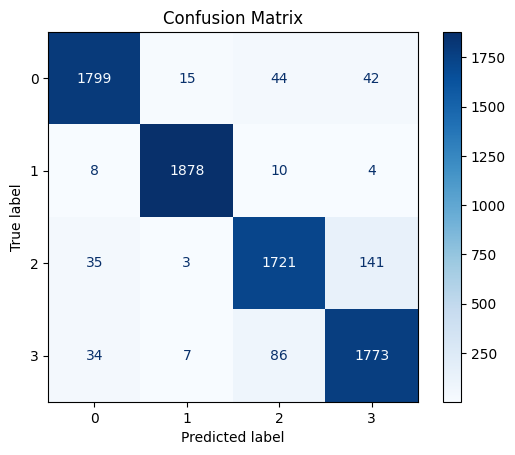

In [127]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [134]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model__x = model__x.to(device)

def tahmin_et(metin):
    inputs = tokenizer(metin, return_tensors="pt", truncation=True, padding=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}  # inputları da aynı device'a taşı
    
    with torch.no_grad():
        outputs = model__x(**inputs)
    
    probs = torch.softmax(outputs.logits, dim=1)
    pred = torch.argmax(probs, dim=1).item()
    confidence = probs[0][pred].item()
    
    print(f"Metin     : {metin}")
    print(f"Tahmin    : Sınıf {pred}")
    print(f"Güven     : %{confidence*100:.1f}")

tahmin_et("Iran and america fighting each other for oil")

Metin     : Iran and america fighting each other for oil
Tahmin    : Sınıf 3
Güven     : %96.9
